In [13]:
# 背景：在09文件跑逻辑回归模型后，发现在保证字段干净的情况下模型性能不太好。
# 但是我们学习逻辑回归模型的目的已经达到，现在开始尝试品牌四象限矩阵。

# 本次目标：构建品牌四象限矩阵，分析品牌在不同象限的分布情况。
# 注意：本分析只使用 A/C 明确结果样本，不包含 B 组。
# 因此这里的“规模”“购买占比”“流失占比”都只代表 A/C 明确结果样本内部的相对表现，
# 不能解释成品牌在全量加购用户中的真实整体转化率。

# 四象限使用两个核心字段：
# - x轴：brand_share_in_clear_outcome（品牌在 A/C 明确结果样本中的体量占比）
# - y轴：c_to_a_ratio（C_count / A_count，主动流失相对购买的风险倍数）
#
# 四个象限：
# - 高体量 × 高风险：重点治理品牌
# - 高体量 × 低风险：核心健康品牌
# - 低体量 × 高风险：问题长尾品牌
# - 低体量 × 低风险：潜力/普通长尾品牌

# 字段工程伪代码模板：
# 1. 读取本地数据库 pgsql 中的 makeup_consumer_events."03_user_behavior_groups" 表，得到 df
# 2. 筛选 group_type 字段为 "A" 和 "C" 的行，得到 df_ac
# 3. 在 groupby 前处理 brand 缺失：
#    - df_ac["brand_clean"] = df_ac["brand"].astype("string").str.strip()
#    - 真正缺失值、空字符串、字符串 "nan"/"null"/"none" 都统一替换为 "Unknown Brand"
# 4. 按 brand_clean 聚合，得到以下字段：
#    - A_count = 该品牌 A 组记录数
#    - C_count = 该品牌 C 组记录数
#    - clear_outcome_count = A_count + C_count
#    - ac_purchase_share = A_count / clear_outcome_count
#    - ac_loss_share = C_count / clear_outcome_count
#    - c_to_a_ratio = C_count / A_count
#    - brand_share_in_clear_outcome = clear_outcome_count / clear_outcome_count.sum()
#
# 字段含义提醒：
# - clear_outcome_count 不是品牌总样本量，而是该品牌在 A/C 明确结果样本中的记录数
# - ac_purchase_share 不是全量购买率，而是 A/C 明确结果中 A 组占比
# - ac_loss_share 不是全量流失率，而是 A/C 明确结果中 C 组占比
# - c_to_a_ratio 越高，说明该品牌相对购买更偏向主动流失

# 特殊情况：
# 1. 仅使用 A/C 明确结果样本
# 2. brand 缺失、空字符串、字符串 NaN/null/none 统一标记为 Unknown Brand
# 3. Unknown Brand 不进入四象限主图，单独统计
# 4. clear_outcome_count < 100 的品牌不进入四象限主图，归为样本不足品牌
# 5. 如果 A_count = 0，c_to_a_ratio 会无法计算或变成无穷大：
#    - 这类品牌不直接进入主图
#    - 单独列为“只有主动流失、没有购买记录”的高风险观察品牌
# 6. 四象限主图只分析：
#    brand != Unknown Brand
#    clear_outcome_count >= 100
#    A_count > 0

# 四象限切分方法（第一版先用中位数，简单且便于解释）：
# - share_threshold = qualified_brands["brand_share_in_clear_outcome"].median()
# - risk_threshold = qualified_brands["c_to_a_ratio"].median()
# - brand_share_in_clear_outcome >= share_threshold 记为高体量，否则低体量
# - c_to_a_ratio >= risk_threshold 记为高风险，否则低风险
#
# 后续如果想更业务化，可以把切分方法改成：
# - 规模：按品牌累计贡献 Top 80% 区分核心品牌/长尾品牌
# - 风险：用 c_to_a_ratio > 1 判断主动流失是否高于购买


In [14]:
import pandas as pd
import numpy as np
import psycopg2
import matplotlib.pyplot as plt
import matplotlib
matplotlib.rcParams['font.sans-serif'] = ['SimHei']
matplotlib.rcParams['axes.unicode_minus'] = False

# 1. 读取数据库
conn = psycopg2.connect(
    host="localhost",
    database="postgres",
    user='postgres',
    password='',
    port=5432
)

df = pd.read_sql('SELECT * FROM makeup_consumer_events."03_user_behavior_groups"', conn)
conn.close()

print(f"原始数据行数: {len(df)}")
print(f"group_type 分布:\n{df['group_type'].value_counts()}")

# 2. 筛选 A/C 明确结果样本
df_ac = df[df["group_type"].isin(["A", "C"])].copy()
print(f"\nA/C 明确结果样本行数: {len(df_ac)}")

# 3. 处理 brand 缺失
df_ac["brand_clean"] = df_ac["brand"].astype("string").str.strip()
unknown_mask = (
    df_ac["brand_clean"].isna() |
    (df_ac["brand_clean"] == "") |
    df_ac["brand_clean"].str.lower().isin(["nan", "null", "none"])
)
df_ac.loc[unknown_mask, "brand_clean"] = "Unknown Brand"

# 4. 按 brand_clean 聚合
brand_stats = df_ac.groupby("brand_clean").agg(
    A_count=("group_type", lambda x: (x == "A").sum()),
    C_count=("group_type", lambda x: (x == "C").sum())
).reset_index()

brand_stats["clear_outcome_count"] = brand_stats["A_count"] + brand_stats["C_count"]
brand_stats["ac_purchase_share"] = brand_stats["A_count"] / brand_stats["clear_outcome_count"]
brand_stats["ac_loss_share"] = brand_stats["C_count"] / brand_stats["clear_outcome_count"]
brand_stats["c_to_a_ratio"] = np.where(
    brand_stats["A_count"] > 0,
    brand_stats["C_count"] / brand_stats["A_count"],
    np.inf
)
brand_stats["brand_share_in_clear_outcome"] = brand_stats["clear_outcome_count"] / brand_stats["clear_outcome_count"].sum()

print(f"\n品牌总数: {len(brand_stats)}")
print(f"前10品牌（按体量排序）:")
print(brand_stats.sort_values("clear_outcome_count", ascending=False).head(10).to_string(index=False))

C:\Users\Administrator\AppData\Local\Temp\ipykernel_11456\1998309516.py:18: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql('SELECT * FROM makeup_consumer_events."03_user_behavior_groups"', conn)


原始数据行数: 1154208
group_type 分布:
group_type
B    518495
C    424063
A    211650
Name: count, dtype: int64

A/C 明确结果样本行数: 635713

品牌总数: 233
前10品牌（按体量排序）:
brand_clean  A_count  C_count  clear_outcome_count  ac_purchase_share  ac_loss_share  c_to_a_ratio  brand_share_in_clear_outcome
        NaN    91028   188571               279599           0.325566       0.674434      2.071571                      0.439820
     runail    18069    31350                49419           0.365629       0.634371      1.735016                      0.077738
      irisk    10496    18828                29324           0.357932       0.642068      1.793826                      0.046128
     masura     6903    21285                28188           0.244891       0.755109      3.083442                      0.044341
    grattol     8119    17377                25496           0.318442       0.681558      2.140288                      0.040106
  bpw.style     6973    11567                18540           0.376106      

In [15]:
# 5. 分离特殊品牌，筛选合格品牌进入四象限
unknown_brand = brand_stats[brand_stats["brand_clean"] == "Unknown Brand"]
print("=== Unknown Brand 统计 ===")
print(unknown_brand.to_string(index=False))

# A_count = 0 的品牌（只有流失没有购买）
zero_purchase_brands = brand_stats[
    (brand_stats["brand_clean"] != "Unknown Brand") & 
    (brand_stats["A_count"] == 0)
]
print(f"\n=== 只有主动流失、没有购买记录的高风险观察品牌: {len(zero_purchase_brands)} 个 ===")
if len(zero_purchase_brands) > 0:
    print(zero_purchase_brands.sort_values("C_count", ascending=False).head(10).to_string(index=False))

# 样本不足品牌
small_brands = brand_stats[
    (brand_stats["brand_clean"] != "Unknown Brand") & 
    (brand_stats["A_count"] > 0) & 
    (brand_stats["clear_outcome_count"] < 100)
]
print(f"\n=== 样本不足品牌 (clear_outcome_count < 100): {len(small_brands)} 个 ===")

# 合格品牌：进入四象限主图
qualified_brands = brand_stats[
    (brand_stats["brand_clean"] != "Unknown Brand") & 
    (brand_stats["clear_outcome_count"] >= 100) & 
    (brand_stats["A_count"] > 0)
].copy()
print(f"\n=== 合格品牌（进入四象限主图）: {len(qualified_brands)} 个 ===")

# 6. 四象限切分（中位数法）
share_threshold = qualified_brands["brand_share_in_clear_outcome"].median()
risk_threshold = qualified_brands["c_to_a_ratio"].median()

print(f"\n切分阈值:")
print(f"  体量中位数 (brand_share_in_clear_outcome): {share_threshold:.6f}")
print(f"  风险中位数 (c_to_a_ratio): {risk_threshold:.4f}")

def assign_quadrant(row):
    high_share = row["brand_share_in_clear_outcome"] >= share_threshold
    high_risk = row["c_to_a_ratio"] >= risk_threshold
    if high_share and high_risk:
        return "重点治理品牌"
    elif high_share and not high_risk:
        return "核心健康品牌"
    elif not high_share and high_risk:
        return "问题长尾品牌"
    else:
        return "潜力/普通长尾品牌"

qualified_brands["quadrant"] = qualified_brands.apply(assign_quadrant, axis=1)

# 各象限品牌数量
print("\n=== 四象限品牌分布 ===")
print(qualified_brands["quadrant"].value_counts())

# 各象限代表品牌
for q in ["核心健康品牌", "重点治理品牌", "潜力/普通长尾品牌", "问题长尾品牌"]:
    subset = qualified_brands[qualified_brands["quadrant"] == q].sort_values(
        "clear_outcome_count", ascending=False
    )
    print(f"\n【{q}】前5:")
    print(subset[["brand_clean", "clear_outcome_count", "ac_purchase_share", "c_to_a_ratio", "brand_share_in_clear_outcome"]].head(5).to_string(index=False))

=== Unknown Brand 统计 ===
Empty DataFrame
Columns: [brand_clean, A_count, C_count, clear_outcome_count, ac_purchase_share, ac_loss_share, c_to_a_ratio, brand_share_in_clear_outcome]
Index: []

=== 只有主动流失、没有购买记录的高风险观察品牌: 10 个 ===
brand_clean  A_count  C_count  clear_outcome_count  ac_purchase_share  ac_loss_share  c_to_a_ratio  brand_share_in_clear_outcome
      kares        0        7                    7                0.0            1.0           inf                      0.000011
 helloganic        0        6                    6                0.0            1.0           inf                      0.000009
       juno        0        4                    4                0.0            1.0           inf                      0.000006
     weaver        0        3                    3                0.0            1.0           inf                      0.000005
        sun        0        2                    2                0.0            1.0           inf                      0.00000

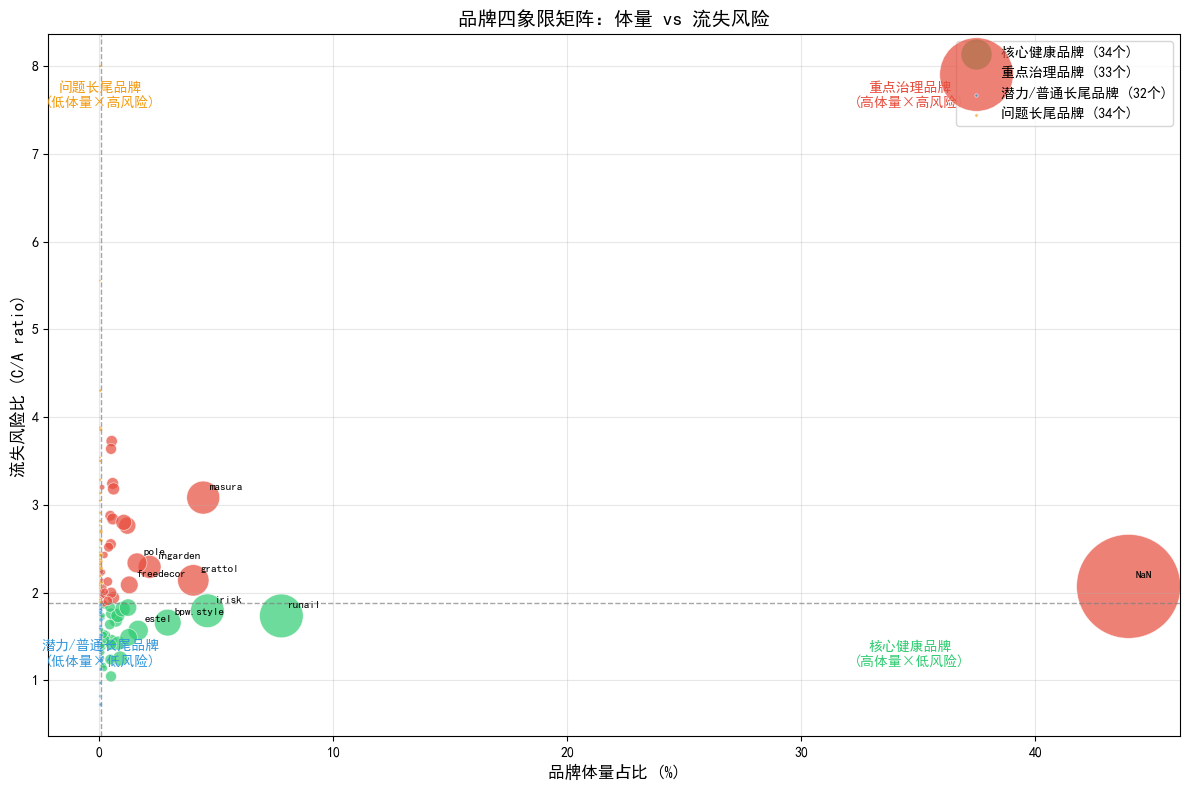

图表已保存: reports/10_brand_quadrant_matrix.png


In [16]:
# 7. 四象限散点图可视化
fig, ax = plt.subplots(figsize=(12, 8))

colors = {
    "核心健康品牌": "#2ecc71",
    "重点治理品牌": "#e74c3c",
    "潜力/普通长尾品牌": "#3498db",
    "问题长尾品牌": "#f39c12"
}

for quadrant, color in colors.items():
    subset = qualified_brands[qualified_brands["quadrant"] == quadrant]
    ax.scatter(
        subset["brand_share_in_clear_outcome"] * 100,
        subset["c_to_a_ratio"],
        c=color,
        label=f"{quadrant} ({len(subset)}个)",
        s=subset["clear_outcome_count"] / 50,
        alpha=0.7,
        edgecolors="white",
        linewidth=0.5
    )

# 标注体量前10的品牌名
top_brands = qualified_brands.nlargest(10, "clear_outcome_count")
for _, row in top_brands.iterrows():
    ax.annotate(
        row["brand_clean"],
        (row["brand_share_in_clear_outcome"] * 100, row["c_to_a_ratio"]),
        fontsize=8,
        ha="left",
        va="bottom",
        xytext=(5, 5),
        textcoords="offset points"
    )

# 画象限分隔线
ax.axvline(x=share_threshold * 100, color="gray", linestyle="--", linewidth=1, alpha=0.7)
ax.axhline(y=risk_threshold, color="gray", linestyle="--", linewidth=1, alpha=0.7)

# 象限标签
xlim = ax.get_xlim()
ylim = ax.get_ylim()
ax.text(xlim[1] * 0.75, ylim[1] * 0.9, "重点治理品牌\n(高体量×高风险)", fontsize=10, color="#e74c3c", ha="center", style="italic")
ax.text(xlim[1] * 0.75, ylim[0] + (ylim[1]-ylim[0])*0.1, "核心健康品牌\n(高体量×低风险)", fontsize=10, color="#2ecc71", ha="center", style="italic")
ax.text(share_threshold * 100 * 0.4, ylim[1] * 0.9, "问题长尾品牌\n(低体量×高风险)", fontsize=10, color="#f39c12", ha="center", style="italic")
ax.text(share_threshold * 100 * 0.4, ylim[0] + (ylim[1]-ylim[0])*0.1, "潜力/普通长尾品牌\n(低体量×低风险)", fontsize=10, color="#3498db", ha="center", style="italic")

ax.set_xlabel("品牌体量占比 (%)", fontsize=12)
ax.set_ylabel("流失风险比 (C/A ratio)", fontsize=12)
ax.set_title("品牌四象限矩阵：体量 vs 流失风险", fontsize=14, fontweight="bold")
ax.legend(loc="upper left", bbox_to_anchor=(1.02, 1), fontsize=10, borderaxespad=0)
ax.grid(True, alpha=0.3)

plt.tight_layout(rect=[0, 0, 0.83, 1])
plt.savefig("../reports/10_brand_quadrant_matrix.png", dpi=150, bbox_inches="tight")
plt.show()
print("图表已保存: reports/10_brand_quadrant_matrix.png")

In [17]:
# 8. 业务解读与品牌分层策略输出
print("=" * 60)
print("品牌四象限矩阵 — 业务解读与运营策略")
print("=" * 60)

quadrant_strategy = {
    "核心健康品牌": "加大流量投入，给资源就能转化，是 GMV 增长的确定性来源",
    "重点治理品牌": "体量大但流失严重，需重点治理：加购挽回弹窗、限时折扣、商详页优化",
    "潜力/普通长尾品牌": "转化健康但体量小，可试探性增加曝光，观察是否能放量",
    "问题长尾品牌": "体量小且流失高，优先级最低，考虑降低推荐权重或淘汰出货盘"
}

for quadrant, strategy in quadrant_strategy.items():
    subset = qualified_brands[qualified_brands["quadrant"] == quadrant]
    print(f"\n【{quadrant}】({len(subset)} 个品牌)")
    print(f"  策略: {strategy}")
    top3 = subset.nlargest(3, "clear_outcome_count")["brand_clean"].tolist()
    print(f"  代表品牌: {', '.join(top3)}")

# 9. 导出品牌分层结果
output_cols = [
    "brand_clean", "quadrant", "A_count", "C_count", "clear_outcome_count",
    "ac_purchase_share", "ac_loss_share", "c_to_a_ratio", "brand_share_in_clear_outcome"
]
result_df = qualified_brands[output_cols].sort_values(
    ["quadrant", "clear_outcome_count"], ascending=[True, False]
)
result_df.to_csv("../data/interim/10_brand_quadrant_matrix.csv", index=False, encoding="utf-8-sig")

print("\n\n" + "=" * 60)
print("品牌分层结果已保存: data/interim/10_brand_quadrant_matrix.csv")
print(f"合格品牌总数: {len(qualified_brands)}")
print(f"被排除品牌: Unknown Brand (1个) + 样本不足 ({len(small_brands)}个) + 无购买记录 ({len(zero_purchase_brands)}个)")
print("=" * 60)

品牌四象限矩阵 — 业务解读与运营策略

【核心健康品牌】(34 个品牌)
  策略: 加大流量投入，给资源就能转化，是 GMV 增长的确定性来源
  代表品牌: runail, irisk, bpw.style

【重点治理品牌】(33 个品牌)
  策略: 体量大但流失严重，需重点治理：加购挽回弹窗、限时折扣、商详页优化
  代表品牌: NaN, masura, grattol

【潜力/普通长尾品牌】(32 个品牌)
  策略: 转化健康但体量小，可试探性增加曝光，观察是否能放量
  代表品牌: eunyul, opi, ardell

【问题长尾品牌】(34 个品牌)
  策略: 体量小且流失高，优先级最低，考虑降低推荐权重或淘汰出货盘
  代表品牌: max, konad, polarus


品牌分层结果已保存: data/interim/10_brand_quadrant_matrix.csv
合格品牌总数: 133
被排除品牌: Unknown Brand (1个) + 样本不足 (90个) + 无购买记录 (10个)
